# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') 
usage = pd.read_csv('/datasets/usage.csv') 

In [3]:
 # mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
 # mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
**Users:** Este dataset tiene dos columnas con valores faltantes: city (11.72%) y churn_date (88,35%).
**Usage:** Este data ser cuenta con 3 columnas con valores faltantes: date (0,12%), duration (55,19%) y lenght(44,74%)
- Indica qué harías: ¿imputar, eliminar, ignorar?
Para la primera tabla **user** se a ignoraran los nulos en **churn_date**, porque significa que los usuarios siguen con sus planes activos. Mientras que para **city** la decisión es imputar, ya que, es una de las variables categóricas centrales para poder segmentar los clientes y observar el comportamiento por lugar.
Para la segunda tabla, **date** los valores nulos se eliminarán, ya que solo son 0.12% lo cual es un número ínfimo de la información recolectada por la empresa. En cuento a **duration(55,19%)** y **lenght (44,74%)** se ignora y se investiga para observar si está alta cantidad de valores nulos esta relacionado a la variable 'type', pues quizás no existen datos porque la acción que se realizó no tiene relación con este tipo de variable, por ejemplo un 'text' no tiene 'duration', mientras que un 'call' no tiene un 'lenght' (esto se puede observar en usage.head(5)).

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
columnas_numericas_users = ['user_id','age']
users[columnas_numericas_users].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` muestra un comportamiento secuencial, lo cual es común en este tipo de datos que sirven de identificación.
- La columna `age` se observa un sentinels **-999**, lo que modifica por completo el análisis, es necesario reemplazarlo por 'pd.NA'.

In [13]:
# explorar columnas numéricas de usage
columnas_numericas_usage=['id','user_id','duration','length']
usage[columnas_numericas_usage].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran un comportamiento esperado para ser llaves de identificación.
- Las columnas `duration` y `lenght` no muestran valores invalidos o sentinels negativos, como en el dataser anterior.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"__Valores únicos para: {col}")
    print(users[col].value_counts(dropna=False))
    print()

__Valores únicos para: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

__Valores únicos para: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` encontramos 469 datos catalogados como NaN, esto significa que son valores nulos, más 96 datos registrados bajo un ?. Ambas anomalías deben estandarizarse bajo la etiqueta de `unknown` 
- La columna `plan` suma 4000 registros, que es la cantidad de datos que reune este dataset, no cuenta con errores de tipeo ni valores nulos.

In [15]:

# explorar columna categórica de usage
print ("Valores único en 'type':")
print (usage['type'].unique())


Valores único en 'type':
['call' 'text']


- La columna `type` tiene las opciones 'call' y 'text'. No se encuentran datos mal escritos ni valores nulos.



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?  
**Users** `age` (Sentinel numérico) se encontro **-999** se recomienda reemplazar con la mediana del grupo, porque es una variable necesaria para la segmentación de clientes.
**Users** `city` (Sentinel categórico) se observaron dos columnas con valores invalidos, **Nan** y **?**, se recomienda crear una nueva columna con la etiqueta `Unknown`
En el dataset **Usage** no se encontraron valores inválidos ni sentinels.  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce') # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce') # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False))


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date` se observa el año 2026, lo cual es imposible, ya que el dataset es hasta el 2024


In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False))

2024.0    39950
NaN          50
Name: date, dtype: int64


En `date`, se observan 50 valores inválidos.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Para `reg_date` para los datos corruptos del 2026, los eliminaría.
Para `date` para los Nan, al orbservar que son 50 datos de 40.000 los eliminaría.
  



---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
print("¿Sigue existiendo el '?' en city?:", "?" in users['city'].unique())

¿Sigue existiendo el '?' en city?: False


In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year<=2024, pd.NaT)

# Verificar cambios
print("Distribución de años en reg_date tras la limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False))


Distribución de años en reg_date tras la limpieza:
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

En `duration` y `length` al agrupar por `type` se puede comprobar que los datos faltantes estan condicionados por el tipo de registro que se tiene, por lo que, son valores nulos por MAR, por lo que estos valores se mantienen, pues son reflejo del normal funcionamiento de la empresa.


## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:

# Renombrar columnas
usage_agg =usage_agg.rename(columns={
    "is_text" : "cant_mensajes",
    "is_call" : "cant_llamadas",
    "duration" : "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")

# observar resultado
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  2.
2. . Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
columnas_num_perfil=['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[columnas_num_perfil].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan

user_profile['plan'].value_counts(normalize=True*100)


Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

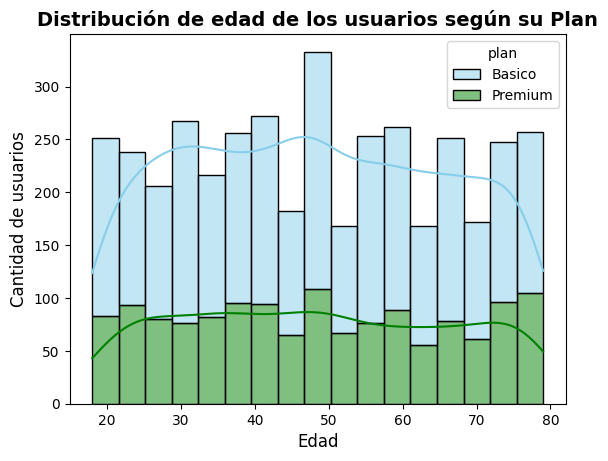

In [35]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,
             x='age',
             hue='plan',
             palette=["skyblue","green"], 
             kde=True, 
             multiple="stack"
)
plt.title("Distribución de edad de los usuarios según su Plan", fontsize=14,fontweight='bold')
plt.xlabel("Edad",fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)
plt.show()


💡Insights: 
- Distribución: se observa una distribución uniforme, es decir, no hay un segmento de edad que domine por sobre otras.
- Uso de plan: existe una mayor cantidad de usuarios en el plan basico.
- No existe una correlación clara entre edad y el tipo de plan que eligen los usuarios.

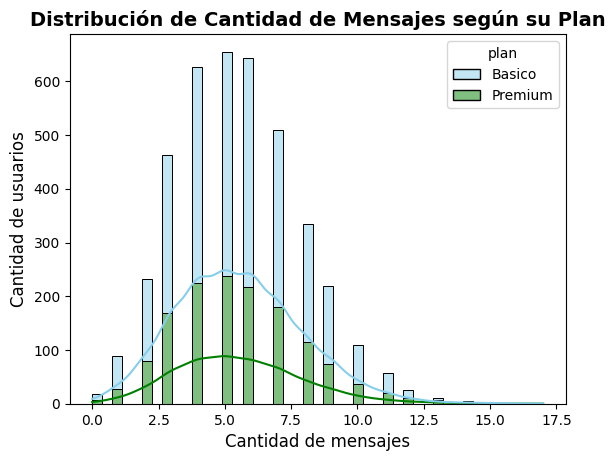

In [41]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue","green"],
    kde=True,
    multiple="stack"
)
plt.title("Distribución de Cantidad de Mensajes según su Plan", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de mensajes", fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)
plt.show()


💡Insights: 
- Distribución: Se observa una distribución normal (acampanada), la moda se observa en 5 mensajes, tanto para el plan básico, como para el premium
- los SMS no son tan utilizados por los clientes, ya que el número máximo de estos es de 17 (para un mes que tiene 30 días)

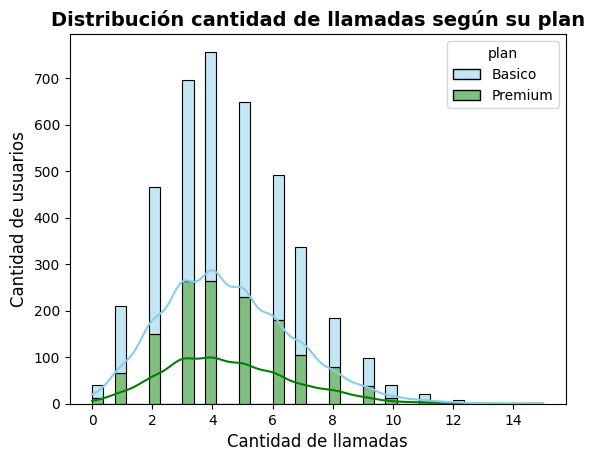

In [43]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue","green"],
    kde= True,
    multiple="stack"
)
plt.title("Distribución cantidad de llamadas según su plan", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de llamadas", fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)
plt.show()


💡Insights: 
- Distribución: se observa una distribución normal (acampanada) la mayor cantidad de usuarios realiza entre 2 y cuatro llamadas.
- Plan: El comportamiento es similar en ambos planes.

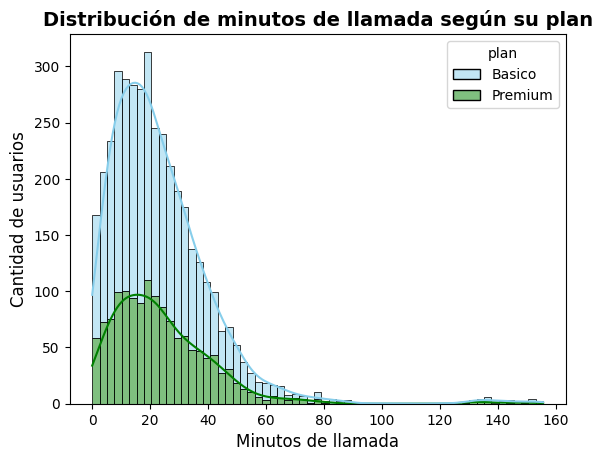

In [44]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue","green"],
    kde=True,
    multiple="stack"
)
plt.title("Distribución de minutos de llamada según su plan", fontsize=14, fontweight="bold")
plt.xlabel("Minutos de llamada", fontsize=12)
plt.ylabel("Cantidad de usuarios",fontsize=12)
plt.show()

💡Insights: 
- Distribución: se puede observar claramente una distribución con sesgo a la derecha, lo que nos indica que existen outliers, que utilizan mayor cantidad de minutos al llamar.
- la mayor cantidad de usuarios utiliza entre 5 y 35 minutos de llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

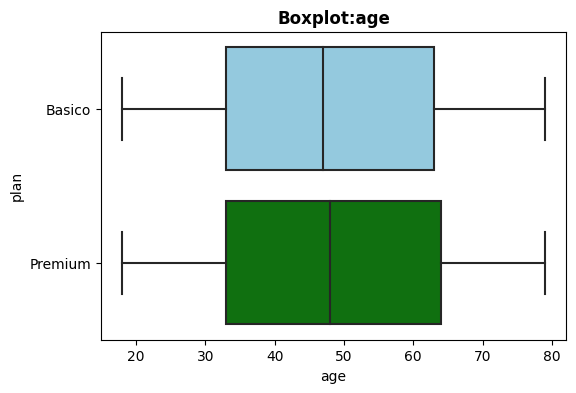

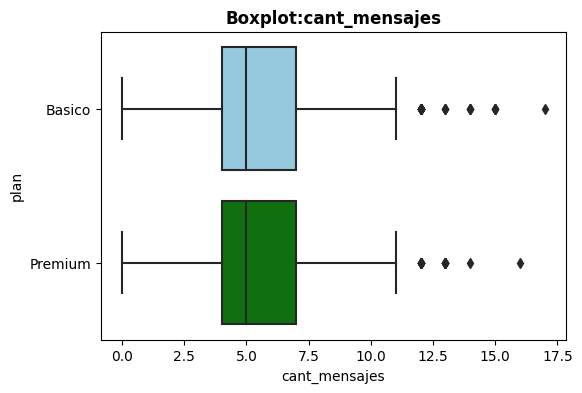

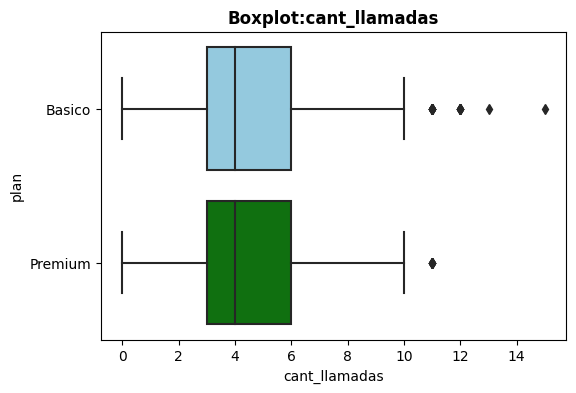

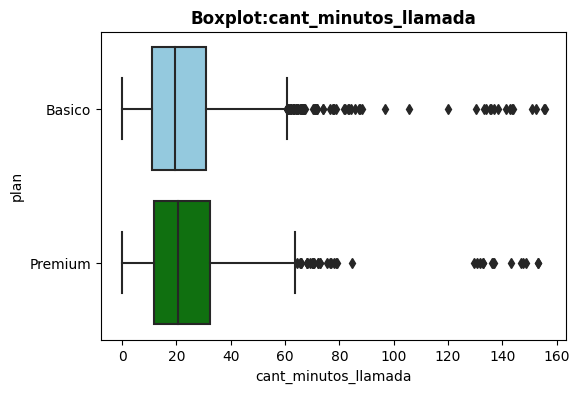

In [46]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas: 
    plt.figure(figsize=(6, 4))
    sns.boxplot(
           data=user_profile,
        x=col,
        y='plan',
        palette=["skyblue","green"]
    )    
    plt.title(f'Boxplot:{col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.show()
    




💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta outliers a la derecha en ambos planes
- cant_llamadas: presenta outliers, en el plan básico presenta más outliers y más extremos, mientras que en el plan premium solo aparece un outlier.
- cant_minutos_llamada: como lo vimos en el histograma presenta outliers extremos en ambos planes y son a la derecha



In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

#for para calcular IQR y límite superior

for col in columnas_limites:
    #cálculo Q1 y Q3
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile [col].quantile(0.75)

    #IQR
    iqr=Q3-Q1

    #Límite Superior
    limite_superior=Q3+1*iqr

    #Conteo cuántos outliers existen
    cantidad_outliers=(user_profile[col]>limite_superior).sum()

    #Impromir resultados
    print(f"Columna: {col}")
    print(f"-Q1: {Q1:.1f} | Q3: {Q3:.1f} | IQR: {iqr:.1f}")
    print(f"-Límite Superior de Outliers: {limite_superior:.2f}")
    print(f"-Cantidad de outliers detectados: {cantidad_outliers}")
    print(f"-Valor máximo registrado: {user_profile[col].max():.2f}")
    print("-" * 60)
    


In [52]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000




💡Insights: 
- cant_mensajes: Mantener los outliers, porque el comportamiento es real, son 17 mensajes máximo en un mes, lo que no parece un comportamiento imposible.
- cant_llamadas: Mantener los outliers, porque al igual que el anterior son 15 llamadas máximo en el mes, lo cual no representa un comportamiento anómalo o imposible, sino que es como se comportan los usuarios de la empresa.
- cant_minutos_llamada: Mantener los outliers, se registra un máximo de 155.69 minutos por llamada, lo que aunque se aleja de la moda y la mediana, y modifica la media, es un comportamiento normal y que se debe tener en cuenta con esos usuarios, sobretodo para poder crear planes para ellos y poderlos segmentar debidamente.



---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [53]:
# Crear columna grupo_uso
condiciones_uso=[
    (user_profile["cant_llamadas"]<5) &(user_profile["cant_mensajes"]<5),

    (user_profile["cant_llamadas"]<10) & (user_profile["cant_mensajes"] <10)
]
opciones_uso=["Bajo uso","Uso medio"]
user_profile['grupo_uso']=np.select(condiciones_uso, opciones_uso, default="Alto uso")


In [54]:

# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [56]:
# Crear columna grupo_edad
condiciones_edad=[
    (user_profile["age"]<30),
    (user_profile["age"]<60)
]
opciones_edad=['Joven','Adulto']

user_profile["grupo_edad"]=np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

In [57]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

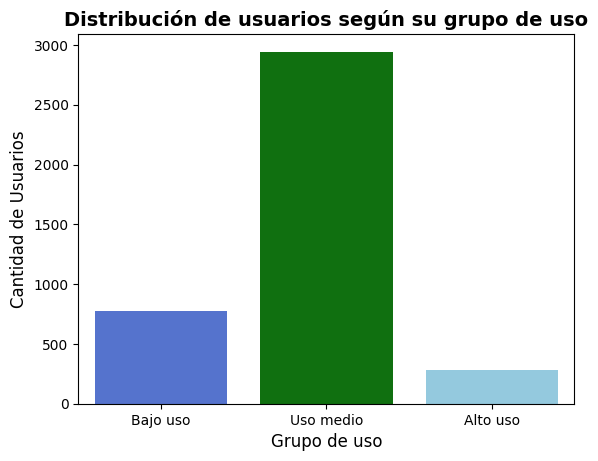

In [65]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso','Uso medio','Alto uso'],
    palette=['royalblue','green','skyblue']
)
plt.title("Distribución de usuarios según su grupo de uso", fontsize=14, fontweight= "bold")
plt.xlabel("Grupo de uso",fontsize=12)
plt.ylabel("Cantidad de Usuarios", fontsize=12)
plt.show()

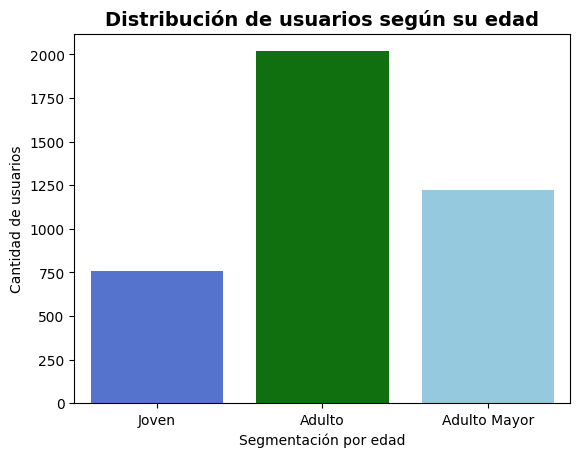

In [67]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    order=['Joven','Adulto','Adulto Mayor'],
    palette=['royalblue','green','skyblue']
)
plt.title("Distribución de usuarios según su edad", fontsize=14,fontweight="bold")
plt.xlabel("Segmentación por edad")
plt.ylabel("Cantidad de usuarios")
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
El primer problema que se encontró en los datos fue el valor -999 en la columna de edad, lo cual fue reemplazado con la mediana de la columna. Ademas se encontró un año imposible porque los datos eran hasta el 2024 y aparecía el 2026, lo cual se capó. Se tuvo que hacer una investigación exhaustiva de la tabla usage, pues existía gran cantidad de valores inválidos en 'duration' y 'length', se llego a la conclusión de que no se trataba de errores de medición, sino de datos ausentes al azar (MAR), se trataba de un "error" que reflejaba el normal funcionamiento de la empresa
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
-->Segmentación por edad:
  - Jóvenes (<30): son el grupo más pequeño (750 usuarios aprox.) tienen hábitos de consumo balanceados y se distribuyen equitativamente en el uso de planes.
  - Adultos (30-59): son el grupo con mayor numero de usuarios (2020 usuarios aprox), es el segmento más activo en todos los servicios (mensajeria, llamada)
  - Adultos Mayores (>=60): Son el segundo grupo de usuarios (1230 usuarios) mantienen un patron de uso constante y al igual que los dos grupos anteriores existe una distribución uniforme en el uso de los planes.
-->Segmentación por nivel de uso:
    -Bajo uso: es un grupo de 780 personas que tienen consumos mínimos de llamadas y mensaje (<5)
    -Uso Medio: Este grupo es el que más usuarios abarca, la mayoria tienen un uso moderado de los servicios de la empresa.
    -Alto Uso: Estos son "súper usuarios" generan traficos intensos en la red de llamadas sobretodo, son aproximadamente 270 usuarios.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- El segmento "adulto mayor": son el segundo grupo de segmentación etaria y tienen un uso uniforme que los demás grupos, pero es normalmente un nicho fiel y con bajo riesgo de abandono
- El segmento de "alto uso": es un grupo pequeño, pero se pueden generar planes para ellos, ya que generan mayor tráfico y rentabilidad.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
    -Mensajes: 103 casos por encima del límite de 10 mensajes, con un máximo de 17.
    -Llamadas: 70 casos sobre el límite de 9 llamadas, llegando hasta 15
    -Minutos de llamada: El hallazgo más notables, 207 outliers superando los 51.71, con un máximo de 155.69 minutos de llamada.

Estos datos al no ser errores del sistema, son usuarios de alto consumo. Su existencia confirma que hay una demanda del servicio de llamada. Algo que la empresa debe tener en cuenta al dimensionar la gestión y logística de su servicio. Además es relevante hablar sobre si realmente sigue siendo un plus hacer gastos publicitarios sobre los mensajes ilimitados, ya que los usuarios no los usan.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
- Hacer un plan senior, tarifas de llamadas y conectividad diferenciada, con ayuda tecnológica y atención al cliente prioritaria. Para poder generar lealtad con este segmento que además de ser amplio, es estable. 
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- `'Age'`: se detectó un 2% (80 filas) con valor -999. Se corrigió mediante el reemplazo con la mediana de la columna.
- `'Valores Nulos'`: se identificaron 22076 nulos en `'duration'` en `'mensajes'` y 17896 nulos en `'lenght'` en la columna `'llamada'`. Son nulos tipo MAR y refleja la operación normal del servicio entregado. Se mantuvieron. 

🔍 **Segmentos por Edad**
- `'Demografía del servicio'`: la base se compone por `'Adultos'` (50.5%), `'Adultos Mayores'` (30,7%) y `'Jóvenes'` (18,7%.)
- La tasa de contratación del plan premium se distribuye de forma equitativa en todas las edades. Lo que quiere decir que la edad no es una variable causal para la elección del plan.


📊 **Segmentos por Nivel de Uso**
- La mayor parte de los usuarios, tiene un `'Uso medio'` (73,7%), seguida por `'Bajo uso'` (19.5%) y `'Alto uso'` (6,8%)

📊**Outliers**
- Se detectaron outiliers de consumo únicamente a la derecha (límite superior): 103 en mensajes, 70 en llamadas y 207 minutos. Esto representa los Heavy Users del servicio y ayudan a observar la capacidad real de la red.
  
➡️ Esto sugiere que:
- La edad no es una barrera digital, los `'Adultos Mayores'` no estan excluidos del mundo digital, son mas activos que los jóvenes, ya que demandan conectividad, por lo que, se pueden hacer campañas específicas para fidelizarlos con la marca.
- Los mensajes de texto no generan un valor por sí mismo, van en retirada, lo que empuja a los usuarios a ser premium no va por "SMS ilimitados".

💡 **Recomendaciones**
- Rediseño "plan premium": eliminar de la campaña los "SMS ilimitados (la moda es de 5 mensajes) y reenfocarlo en datos moviles y bolsas de minutos de larga duración.
- Crear un plan "Senior": Lanzar productos focalizados a los adultos mayores, ofreciendo tarifas competitivas de voz y atención al cliente prioritario, además de posible alfabetización tecnológica o apoyo tecnológico.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`